# TVAM AID: Penalty Approach Demonstration

## 1. Problem Definition

Illumination planning is an optimisation problem in which a non-negative illumination plan is sought whose back-projection produces an achieved dose field with desirable characteristics in the in-part and out-of-part regions.

A central feature of the TVAM AID formulation is the freedom to define different penalty functions for these regions. This notebook demonstrates the four approaches currently implemented in TVAM AID:
- L2N: L2-norm penalties centred on prescribed lower and upper dose thresholds.
- OSP: one-sided penalties that do not penalise out-of-part doses below the lower threshold or in-part doses above the upper threshold.
- OSPW($w>0.0$): extends OSP with an additional penalty on high in-part dose. The parameter $w$ controls the width of the no-penalty region above the upper threshold.
- OSPW($w=0.0$): a special case of OSPW(w>0.0) that reduces the in-part penalty to an L2-norm and retains a one-sided penalty out-of-part.

The notebook introduces the complete TVAM AID workflow: loading a target geometry, constructing the TVAM operator, defining and solving the optimisation problem, evaluating the resulting dose field, and visualising the illumination plan and achieved dose.

## 2. Configuration

In [1]:
from tvam_aid import RunConfig, Thresholds, loadTargetGeometry, showTarget, \
    nonNegativityConstraint, runOptimisation, printMetrics, \
    plotAchievedDose2D, plotHistogram
from tvam_aid.penalties import L2N, OSP, OSPW
from tvam_aid.operators import createLinearOperator
from tvam_aid.callbacks import RecordMetrics, Progress
import numpy as np

In [2]:
# select the target geometry
pathToTarget = '../targets/DTULogo.npy'

# select which approach to use from L2N(), OSP(), OSPW(w=...)
approach = OSPW(w=0.0)

# define settings for this run
config = RunConfig(
    device = 'gpu',
    numIters = 1000,
    angles = np.linspace(0, 360, 360*4, endpoint=False)
)

# define the upper and lower thresholds
thresholds = Thresholds(
    lower = 0.7,
    upper = 0.9
)

# define which callbacks to use in the optimisation
metrics = RecordMetrics()
progress = Progress()

## 3. Load Target Geometry

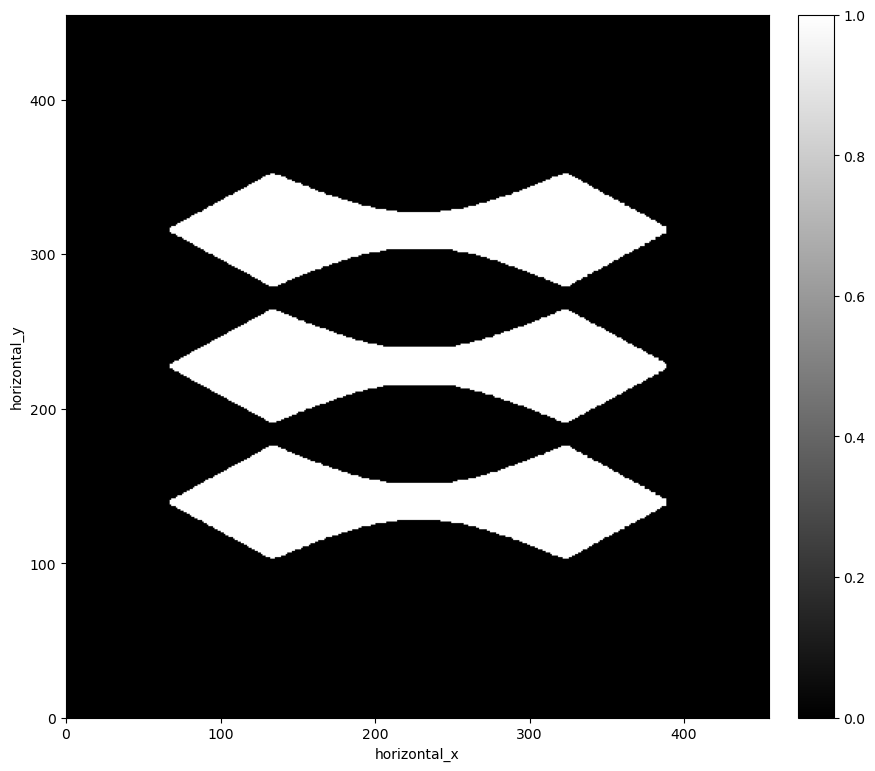

In [3]:
target = loadTargetGeometry(pathToTarget)
showTarget(target)

## 4. Construct the TVAM Operator

In [4]:
tvamOperator = createLinearOperator(target, config)

## 5. Define the Optimisation Problem

In [5]:
objective = approach.build(tvamOperator, target, thresholds)
constraint = nonNegativityConstraint()

## 6. Solve

In [6]:
metricsCallback = metrics.build(target, thresholds, tvamOperator)
progressCallback = progress.build()
callbacks = [metricsCallback, progressCallback]

illuminationPlan, achievedDose = runOptimisation(objective, constraint, target, tvamOperator, config, callbacks)

  0%|          | 0/1000 [00:00<?, ?it/s]

## 7. Evaluate the Achieved Dose

In [7]:
printMetrics(metricsCallback)


=== METRICS ===
IPDR  ¦ 0.00803
PW    ¦ 0.19409
VER   ¦ 0.00000


## 8. Visualise the Achieved Dose

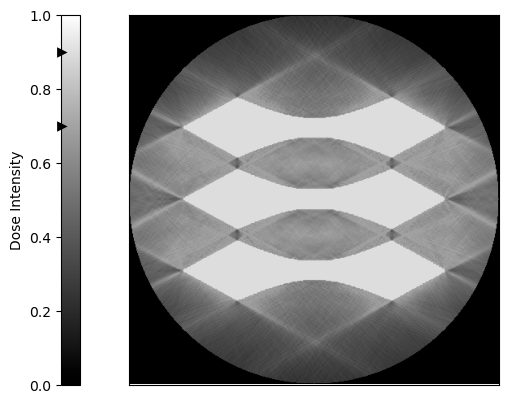

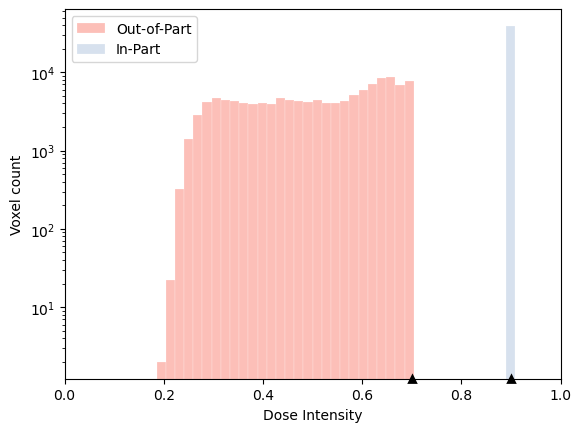

In [8]:
fig1, ax1 = plotAchievedDose2D(achievedDose, target, thresholds)
fig2, ax2 = plotHistogram(achievedDose, target, thresholds)